#  Model Selection & Experimenting

## Objective
เปรียบเทียบ ML Model หลายๆตัวในการ predict commission_level (High vs Low) โดยใช้ features ที่เตรียมไว้จาก 02_data_preparation.ipynb

**Model to be tested**
1. **Logistic Regression (Baseline)** : เพื่อดูว่า relationship ระหว่าง feature กับ target เป็น linear เปล่า
2. **Decision Tree** : ใช้ทดสอบความสามารถในการจับ rule-based และ interaction ระหว่าง feature แบบ non-linear
3. **Random Forest**: ใช้เป็น ensemble model เพื่อเพิ่มความเสถียรและลด overfitting จาก Decision Tree

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Tahoma'

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)

print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train: (673, 11) | Test: (169, 11)
Train target distribution:
commission_level
0    0.502229
1    0.497771
Name: proportion, dtype: float64
Test target distribution:
commission_level
0    0.502959
1    0.497041
Name: proportion, dtype: float64


## 1. Model Selection

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

print("=" * 60)
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'F1 (Test)':>10}")
print("=" * 60)

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test, y_pred_test)
    f1        = classification_report(
        y_test, y_pred_test,
        output_dict=True
    )['weighted avg']['f1-score']
    
    results.append({
        "Model": name,
        "Train Acc": round(train_acc, 4),
        "Test Acc": round(test_acc, 4),
        "F1 (Test)": round(f1, 4),
        "Overfit": "Yes" if (train_acc - test_acc) > 0.10 else "No"
    })
    
    print(f"{name:<25} {train_acc:>10.4f} {test_acc:>10.4f} {f1:>10.4f}")

print("=" * 60)

results_df = pd.DataFrame(results)\
    .sort_values("Test Acc", ascending=False)\
    .reset_index(drop=True)

print("Summary Table")
print(results_df.to_string(index=False))

Model                      Train Acc   Test Acc  F1 (Test)
Logistic Regression           0.5513     0.5444     0.5435
Decision Tree                 0.7801     0.5917     0.5750
Random Forest                 0.7801     0.6154     0.6078
Summary Table
              Model  Train Acc  Test Acc  F1 (Test) Overfit
      Random Forest     0.7801    0.6154     0.6078     Yes
      Decision Tree     0.7801    0.5917     0.5750     Yes
Logistic Regression     0.5513    0.5444     0.5435      No


**Insights**   
- **Logistic Regression** มี performance ต่ำสุด (Test Accuracy = 0.54)   
    แสดงให้เห็นว่าความสัมพันธ์ในข้อมูลอาจไม่สามารถอธิบายได้ด้วย linear boundary เพียงอย่างเดียว
- **Decision Tree** มี performance ดีขึ้น (Test Accuracy = 0.59)   
    สามารถจับ pattern แบบ non-linear ได้ แต่ก็ยังมีความผันผวนของโมเดล
- **Random Forest** ให้ผลดีที่สุด (Test Accuracy = 0.62, F1 = 0.60)   
    แสดงถึงความสามารถในการเรียนรู้ pattern ที่ซับซ้อนมากขึ้นผ่าน ensemble method
- แต่มี **Overfitting** เล็กน้อย ทั้ง Decision Tree และ Random Forest มี train accuracy 0.78 เเต่ test accuracy ลดลงเหลือ 0.61 แสดงให้เห็นว่า model เรียนรู้ pattern จาก training data ได้ดี แต่ยัง generalize กับ unseen data ได้ไม่เต็มที่

## 2. Model Comparison Visualization 

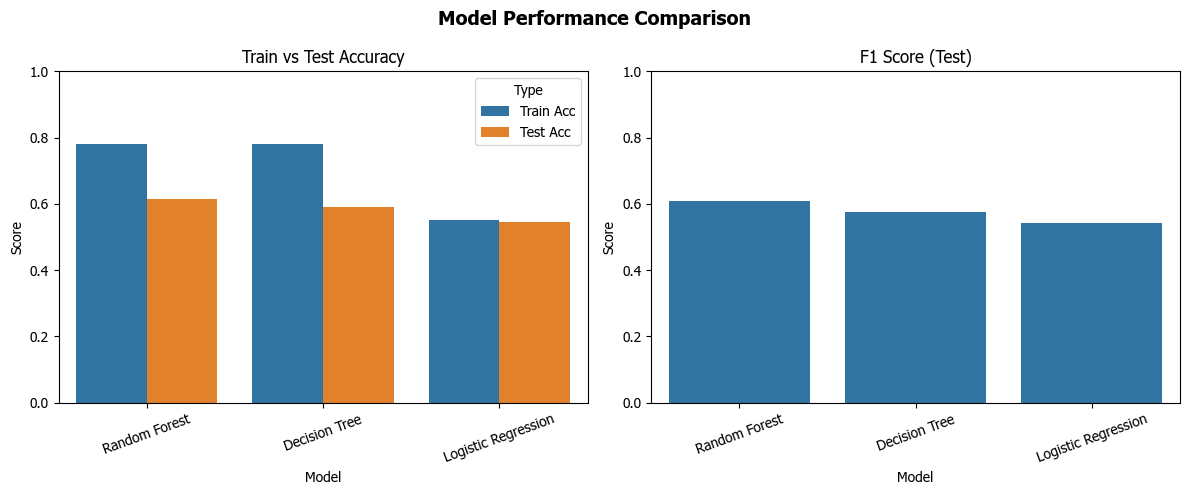

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold')

# Accuracy plot
acc_df = results_df.melt(
    id_vars="Model",
    value_vars=["Train Acc", "Test Acc"],
    var_name="Type",
    value_name="Accuracy"
)

sns.barplot(data=acc_df, x="Model", y="Accuracy", hue="Type", ax=axes[0])
axes[0].set_title("Train vs Test Accuracy")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].tick_params(axis='x', rotation=20)

# F1-score plot
sns.barplot(data=results_df, x="Model", y="F1 (Test)", ax=axes[1])
axes[1].set_title("F1 Score (Test)")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Score")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Insights**    
Random Forest ให้ผลดีที่สุดทั้ง Accuracy และ F1-score เพราะมีความสามารถในการ generalize ดีกว่า แต่พวก Tree-based model ยังมีช่องว่างระหว่าง Train และ Test accuracy ซึ่งแสดงให้เห็นว่ามีแนวโน้ม overfitting เล็กน้อย

## 3. Select Best Model

In [7]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_row['Test Acc']:.4f}")
print(f"F1 Score: {best_row['F1 (Test)']:.4f}")

Best Model: Random Forest
Test Accuracy: 0.6154
F1 Score: 0.6078


## 4. Confusion Matrix

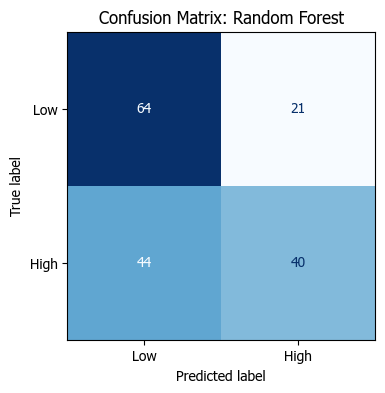

In [8]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "High"]
)

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Confusion Matrix: {best_model_name}")

plt.show()

**Insights**   
- **TP**: Model ทายว่า High และผลจริงคือ High ได้ถูกต้องจำนวน 40 
- **TN**: Model ทายว่า Low และผลจริงคือ Low ได้ถูกต้องจำนวน 64
- **FP**: Model ทายว่า High แต่ผลจริงคือ Low ผิดพลาดไป 21
- **FN**: Model ทายว่า Low แต่ผลจริงคือ High ผิดพลาดไป 44

Model มี performance เพียงพอสำหรับการใช้งานเชิง decision support โดยสามารถแยก Low และ High ได้ในระดับที่เหมาะสม แม้ยังมี error ในการจับ High บางส่วนบ้าง

## 5. Save Model

In [9]:
import joblib

model_path = f"../models/best_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, model_path)

results_df.to_csv("../outputs/model_results.csv", index=False)